# Accessing the Digital Earth Normalised Radar Backscatter Product for Sentinel-1 (Collection 0) Using the STAC API

This notebook shows a number of additional features that can be taken advantage of when loading through Digital Earth's STAC API.

## Important STAC terminology
The STAC standard has four important components:

* **Catalog**: A structure for organising multiple datasets managed by a given provider.
* **Collection**: A structure for organising all items in a single dataset.
* **Item** A single spatio-temporal item, such as one observation in a dataset.
* **Asset** A single data measurement associated with an item, such as a single band.

For the Normalised Radar Backscatter data, it is important to note that a single *item* corresponds to a single *burst* from a larger acquisition.

## Set-up

### Import required libraries
To use STAC on DE Sandbox you need to make sure you are using pystac 1.12.1 or newer.

In [1]:
pip install pystac==1.12.1

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from odc.geo import BoundingBox
import xarray as xr
from pystac_client import Client
from odc.stac import load, configure_s3_access

### Environment set up

In [3]:
catalog = "https://explorer.dev.dea.ga.gov.au/stac"
stac_client = Client.open(catalog)
configure_s3_access(cloud_defaults=True, aws_unsigned=True)

## Interrogating the catalog and collections

### Available collections

The following collections are available in the collection 1 data release:
* `ga_s1_nrb_iw_hh_1`
* `ga_s1_nrb_iw_hh_hv_1`
* `ga_s1_nrb_iw_vv_1`
* `ga_s1_nrb_iw_vv_vh_1`

### View collection metadata

Displaying the result from `get_collection()` will provide an expandable JSON output showing the collection-level metadata. 

In [4]:
collection = stac_client.get_collection("ga_s1_nrb_iw_hh_1")

collection

<CollectionClient id=ga_s1_nrb_iw_hh_1>

### View dataset metadata

Many additional metadata properties are available on a dataset level. For this example, we show the metadata associated with a specific item, [ga_s1b_nrb_1-0-0_T003-005802-IW2_20200113T222629Z](https://explorer.dev.dea.ga.gov.au/products/ga_s1_nrb_iw_hh_1/datasets/692f0428-5cb7-5ee1-84df-73099e99027b), which has a dataset id of `692f0428-5cb7-5ee1-84df-73099e99027b`

Displaying the first result from the `item_collection` will provide an expandable JSON output. 
The additional metadata properties and their values can be found under `properties`.

In [5]:
single_item = stac_client.search(
    collections=["ga_s1_nrb_iw_hh_1"],
    ids=["692f0428-5cb7-5ee1-84df-73099e99027b"]

).item_collection()

single_item[0]

<Item id=692f0428-5cb7-5ee1-84df-73099e99027b>

## Basic search and load
When working with the STAC API, there are two steps: 
1. Searching the collection for items that match a query using `pystac-client`
2. Loading the discovered items into an xarray with `odc-stac`

The following shows a basic search and load

### Set search parameters

These are primarily used by the search step, but may also be re-used in load

In [6]:
# Collections to query
collections_to_search = ["ga_s1_nrb_iw_hh_1"]

# Area of interest
aoi_bbox = BoundingBox(
    left=73.5,
    bottom=-69.1,
    right=74.0,
    top=-68.8,
    crs="EPSG:4326"
)

start_date = "2021-01-01"
end_date = "2021-03-01"

aoi_bbox.explore()

### Run search

Note that the search function takes:
* `collections`: a list of collections.
* `datetime`: a date range in the format `"{start}/{end}"`.
* `intersects`: a geometry to intersect.

See the [API](https://pystac-client.readthedocs.io/en/latest/api.html#pystac_client.Client.search) for more information.

In [7]:
items = stac_client.search(
    collections=collections_to_search,
    datetime=f"{start_date}/{end_date}",
    intersects=aoi_bbox.boundary(),
).item_collection()

print(f"Found {len(items)} items")

Found 45 items


### View item-level metadata

Before loading, it can be valuable to understand the general metadata properties of the returned items.
For example, are your items primarily captured in descending or ascending passes? 

In [8]:
ascending_items = [item for item in items if item.properties["sat:orbit_state"]=="ascending"]
print(f"Number of items with ascending orbit state: {len(ascending_items)}")

descending_items = [item for item in items if item.properties["sat:orbit_state"]=="descending"]
print(f"Number of items with descending orbit state: {len(descending_items)}")

Number of items with ascending orbit state: 15
Number of items with descending orbit state: 30


Alternatively, you could look at the number of unique absolute orbits (tracks) or scenes across your items.

In [9]:
unique_relative_orbits = set([item.properties["sat:relative_orbit"] for item in items])
print(f"The identified items come from {len(unique_relative_orbits)} unique relative orbits")
print(f"The unique relative orbit values are: {unique_relative_orbits}\n")

unique_absolute_orbits = set([item.properties["sat:absolute_orbit"] for item in items])
print(f"The identified items come from {len(unique_absolute_orbits)} unique absolute orbits")
print(f"The unique absolute orbit values are: {unique_absolute_orbits}\n")

unique_scene_ids = set([item.properties["sarard:scene_id"] for item in items])
print(f"The identified items come from {len(unique_scene_ids)} unique scenes")
print(f"The unique scene ids are: {unique_scene_ids}")


The identified items come from 2 unique relative orbits
The unique relative orbit values are: {3, 28}

The identified items come from 15 unique absolute orbits
The unique absolute orbit values are: {36675, 36325, 35975, 36650, 25579, 36300, 25229, 35950, 36500, 36150, 25754, 36475, 25404, 36125, 25054}

The identified items come from 15 unique scenes
The unique scene ids are: {'S1A_IW_SLC__1SSH_20210103T154451_20210103T154521_035975_0436F4_0DC0', 'S1B_IW_SLC__1SSH_20210107T222652_20210107T222719_025054_02FB76_B297', 'S1B_IW_SLC__1SSH_20210131T222651_20210131T222718_025404_03069E_D500', 'S1A_IW_SLC__1SSH_20210206T222733_20210206T222800_036475_044851_E12D', 'S1A_IW_SLC__1SSH_20210127T154450_20210127T154520_036325_04432E_74A7', 'S1A_IW_SLC__1SSH_20210208T154450_20210208T154520_036500_04493D_773C', 'S1A_IW_SLC__1SSH_20210113T222734_20210113T222801_036125_043C3C_8C68', 'S1B_IW_SLC__1SSH_20210119T222652_20210119T222719_025229_030111_642A', 'S1A_IW_SLC__1SSH_20210220T154450_20210220T154520_03

### Set load parameters

These parameters specify how the data should be loaded, including which assets (bands) to load, the desired coordinate reference system and resolution, and how data should be grouped (discussed more later in this notebook). The recommended default grouping operation is `"solar_day"`, which combines all observations captured on a single day into one time-step in the loaded xarray.

In [10]:
# Assets to load
assets_to_load = ["hh_gamma0", "oa_layover_shadow_mask"]

# CRS and resolution
output_crs = "3031"
output_res = 200 # When loading a larger area, you can save time and memory by increasing the pixel size (lower resolution)

# Property or function to group by. "solar_day" is already built into odc-stac
groupy_by_operation = "solar_day"

### Run load

Note that the load function takes:
* `items`: a pystac-client items_collection
* `bands`: a list of assets to load
* `intersects`: a geometry to intersect
* `crs`: a coordinate reference system for the output
* `resolution`: a resolution for the output
* `groupby`: a method or property to group by
* `chunks`: (optionally) a dictionary describing how to chunk the data for lazy loading (recommended)

See the [API](https://odc-stac.readthedocs.io/en/latest/_api/odc.stac.load.html) for more information.

In [11]:
ds = load(
    items=items,
    bands=assets_to_load,
    intersects=aoi_bbox.boundary(),
    crs=output_crs,
    resolution=output_res,
    groupby=groupy_by_operation,
    chunks={},
)

### View the lazy-loaded xarray

In [12]:
ds

<xarray.Dataset> Size: 57MB
Dimensions:                 (y: 808, x: 590, time: 15)
Coordinates:
  * y                       (y) float64 6kB 7.225e+05 7.223e+05 ... 5.611e+05
  * x                       (x) float64 5kB 2.132e+06 2.132e+06 ... 2.25e+06
    spatial_ref             int32 4B 3031
  * time                    (time) datetime64[ns] 120B 2021-01-01T22:27:35.86...
Data variables:
    hh_gamma0               (time, y, x) float32 29MB dask.array<chunksize=(1, 808, 590), meta=np.ndarray>
    oa_layover_shadow_mask  (time, y, x) float32 29MB dask.array<chunksize=(1, 808, 590), meta=np.ndarray>

### Compute the lazy loaded xarray
To save time and memory for this demonstration, we'll only compute the first three time-steps.

In [13]:
ds = ds.isel(time=range(0,3)).compute()

ds

/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


<xarray.Dataset> Size: 11MB
Dimensions:                 (y: 808, x: 590, time: 3)
Coordinates:
  * y                       (y) float64 6kB 7.225e+05 7.223e+05 ... 5.611e+05
  * x                       (x) float64 5kB 2.132e+06 2.132e+06 ... 2.25e+06
    spatial_ref             int32 4B 3031
  * time                    (time) datetime64[ns] 24B 2021-01-01T22:27:35.868...
Data variables:
    hh_gamma0               (time, y, x) float32 6MB nan nan nan ... nan nan nan
    oa_layover_shadow_mask  (time, y, x) float32 6MB nan nan nan ... nan nan nan

### Visualise

This step shows how to visualise the first three time-steps from the xarray.
After grouping by solar day, you can see how the Sentinel-1 orbit tracks influence where data is and isn't captured on a given day.

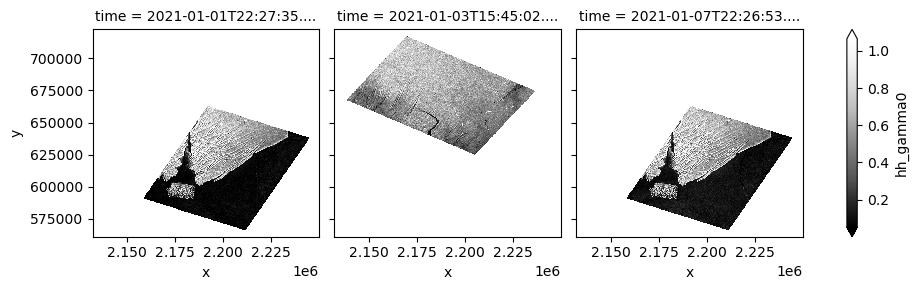

In [14]:
ds.isel(time=range(0,3))["hh_gamma0"].plot.imshow(col="time", col_wrap=3, robust=True, cmap="Greys_r")

## Advanced approaches

### Filtering on metadata values

It is possible to filter on the various metadata properties as part of the search step, which can be valuable for ensuring consistency of data.
For example, with Sentinel-1, you may wish to filter your datasets to only load those observed on descending or ascending paths.
See the [01_product_info](01_product_info.ipynb) notebook for a table containing key metadata that can be used when searching and loading.

Pystac-client uses the [Common Query Language](https://docs.ogc.org/is/21-065r2/21-065r2.html) standard to search on metadata fields. 
In Python, it's a dictionary with two keys:
* `"op"` which sets the operation to conduct, e.g. `"="`, `"<="`, `"and"`, `"not"`
* `"args"` which is a list containing the property and the value to apply the operation to

The pystac-client documentation has some [examples](https://pystac-client.readthedocs.io/en/stable/tutorials/cql2-filter.html#CQL2-Filters).

Below, we show how to filter items for a single known `scene_id`.
There may be multiple items for a single scene, since items correspond to bursts, rather than scenes, and there are typically 20-30 bursts per scene.

In [15]:
scene_filter = {
    "op": "=",
    "args": [{"property": "sarard:scene_id"}, "S1A_IW_SLC__1SSH_20210208T154450_20210208T154520_036500_04493D_773C"]
}

scene_items = stac_client.search(
    collections=collections_to_search,
    datetime=f"{start_date}/{end_date}",
    intersects=aoi_bbox.boundary(),
    filter=scene_filter,
).item_collection()

print(f"Found {len(scene_filter)} items")

Found 2 items


### Advanced load

While `odc.stac` implements the option to group by `"solar_day"` it is also possible to group by an arbitrary metadata property. 
The below example groups items by scene, rather than by solar day.

In [16]:
ds_by_scene = load(
    items=items,
    bands=assets_to_load,
    intersects=aoi_bbox.boundary(),
    crs=output_crs,
    resolution=output_res,
    groupby="sarard:scene_id",
    chunks={},
)

The effect of grouping by scene is that there are a different number of time-steps, one per scene.

In [17]:
ds_by_scene

<xarray.Dataset> Size: 57MB
Dimensions:                 (y: 808, x: 590, time: 15)
Coordinates:
  * y                       (y) float64 6kB 7.225e+05 7.223e+05 ... 5.611e+05
  * x                       (x) float64 5kB 2.132e+06 2.132e+06 ... 2.25e+06
    spatial_ref             int32 4B 3031
  * time                    (time) datetime64[ns] 120B 2021-01-01T22:27:35.86...
Data variables:
    hh_gamma0               (time, y, x) float32 29MB dask.array<chunksize=(1, 808, 590), meta=np.ndarray>
    oa_layover_shadow_mask  (time, y, x) float32 29MB dask.array<chunksize=(1, 808, 590), meta=np.ndarray>

The impact of grouping by scene is also visible when displaying the data.

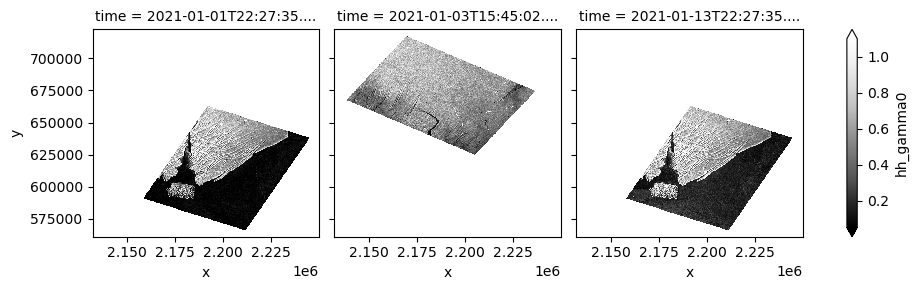

In [18]:
ds_by_scene.isel(time=range(0,3))["hh_gamma0"].plot.imshow(col="time", col_wrap=3, robust=True, cmap="Greys_r")